ValueError: Received invalid argument(s): background_color

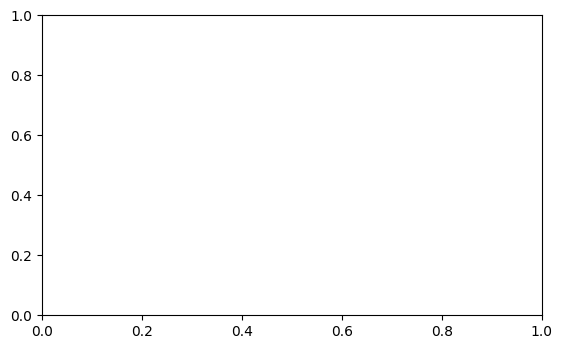

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_graph(adjacency_list, weighted=False):
    """ 
    Plot a graph from an adjacency list with optional weights.
    adjacency_list: dict where keys are nodes, values are lists of tuples (neighbor, weight) if weighted, 
                    or lists of neighbors if unweighted.
    weighted: bool indicating if graph is weighted.
    """
    G = nx.DiGraph()  # Use DiGraph for directed graphs

    # Add edges
    for node, neighbors in adjacency_list.items():
        if weighted:
            G.add_weighted_edges_from((node, neighbor, weight) for neighbor, weight in neighbors)
        else:
            G.add_edges_from((node, neighbor) for neighbor in neighbors)

    # Auto-generate positions using a tree layout
    pos = _binary_tree_layout(G, list(adjacency_list.keys())[0])

    # Draw the graph
    plt.figure(figsize=(5, 3))
    nx.draw(
        G, pos, with_labels=True, 
        node_color='lightblue', 
        node_size=400, 
        font_size=10, font_weight='bold', font_color="white"
    )

    # Add edge labels if weighted
    if weighted:
        edge_labels = nx.get_edge_attributes(G, 'weight')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=12, label_pos=0.5)

    plt.title("Graph Visualization")
    plt.show()


def _binary_tree_layout(G, root, width=2.0, height=1.0, x_offset=0.0, y_offset=0.0, layer_sep=1.5, pos=None, level=0, visited=None):
    """ Recursively generate positions for a binary tree-like layout with cycle detection. """
    if pos is None:
        pos = {}
    if visited is None:
        visited = set()

    # Skip if the node has already been visited (to prevent cycles)
    if root in visited:
        return pos
    visited.add(root)

    children = list(G.successors(root))
    if not children:
        pos[root] = (x_offset, y_offset)
    else:
        mid = len(children) // 2
        for i, child in enumerate(children):
            dx = width / 2 ** (level + 1)
            next_x = x_offset + (i - mid) * dx
            next_y = y_offset - layer_sep
            _binary_tree_layout(G, child, width, height, next_x, next_y, layer_sep, pos, level + 1, visited)
        pos[root] = (x_offset, y_offset)

    return pos


adj_list_unweighted = {
    'A': ['B', 'C', 'D'],
    'B': ['E', 'F'],
    'C': ['G'],
    'D': ['H'],
    'E': [],
    'F': ['I', 'J'],
    'G': ['K'],
    'H': [],
    'I': [],
    'J': [],
    'K': []
}

plot_graph(adj_list_unweighted, weighted=False)